# 73 - SNP directos PCA + MLP (Nested CV 5x3) - 7 traits

## Objetivo

Evaluar una variante mas estable del MLP sobre SNPs directos. En lugar de introducir todos los marcadores directamente en la primera capa, este cuaderno aplica una compresion PCA ajustada solo con los datos de entrenamiento de cada fold y entrena despues una red pequena y regularizada.

Aspectos clave:

- Se mantiene el esquema **Nested CV 5x3** para comparabilidad con el resto del proyecto.
- La compresion PCA se ajusta dentro de cada fold para evitar leakage.
- Se tunean `n_components`, `learning_rate` y `batch_size` con un grid pequeño.
- El objetivo es reducir sobreajuste y mejorar estabilidad frente al MLP_A directo del cuaderno 72.
- Los resultados se guardan en `results/...`.


In [1]:
# 1) Librerias y parametros globales

from pathlib import Path
import re
import random
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import pearsonr

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, regularizers
except Exception as exc:
    raise ImportError(
        "TensorFlow/Keras no esta disponible en este entorno. Instala tensorflow para ejecutar este notebook."
    ) from exc

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

# =========================
# Rutas relativas
# =========================
RAW_REL = Path("merged_all_mind0.20_g0.10_mac1_nomaf_pruned_raw.raw")
PHENO_REL = Path("pheno_data/BLUEs_across_env.tsv")
META_REL = Path("pheno_data/giae121_supplemental_file.xlsx")
META_HEADER_ROW = 2

OUTPUT_REL = Path("results/nn_snp_pca_nested5x3")
CHECKPOINT_REL = OUTPUT_REL / "checkpoints"

BASELINE_MLP72_REL = Path("results/nn_snp_nested5x3/nn_snp_nested5x3_summary.csv")
BASELINE_GBLUP_REL = Path("results/snp_blocks_notebook_nested5x3_gblup/gblup_results.csv")

# =========================
# Traits
# =========================
TRAITS = [
    "blumeria_graminis",
    "heading_date",
    "lodging",
    "plant_height",
    "puccinia_hordei",
    "ramularia_collo_cygni",
    "rhynchosporium",
]

# =========================
# Nested CV
# =========================
OUTER_SPLITS = 5
INNER_SPLITS = 3
MAX_EPOCHS = 300
INNER_VAL_SIZE = 0.20

# =========================
# Config grid
# =========================
CONFIG_GRID_BY_TRAIT = {
    "lodging": [
        {"n_components": 64, "learning_rate": 1e-3, "batch_size": 16},
        {"n_components": 128, "learning_rate": 1e-3, "batch_size": 16},
        {"n_components": 64, "learning_rate": 5e-4, "batch_size": 16},
    ],
    "ramularia_collo_cygni": [
        {"n_components": 64, "learning_rate": 1e-3, "batch_size": 32},
        {"n_components": 128, "learning_rate": 1e-3, "batch_size": 32},
    ],
}

DEFAULT_GRID = [
    {"n_components": 64, "learning_rate": 1e-3, "batch_size": 32},
    {"n_components": 128, "learning_rate": 1e-3, "batch_size": 32},
    {"n_components": 64, "learning_rate": 5e-4, "batch_size": 32},
    {"n_components": 128, "learning_rate": 5e-4, "batch_size": 32},
]

EARLY_STOP_PATIENCE = 30
REDUCE_LR_PATIENCE = 10
REDUCE_LR_FACTOR = 0.5
MIN_LR = 1e-6
PCA_SVD_SOLVER = "randomized"
VERBOSE_FIT = 0

RAW_ID_COLS = ["FID", "IID", "PAT", "MAT", "SEX", "PHENOTYPE"]

print("TensorFlow:", tf.__version__)


TensorFlow: 2.18.0


In [2]:
# 2) Resolucion de rutas y salida

def resolve_base_dir():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "nested5x3_unificados",
        cwd.parent,
        cwd.parent / "nested5x3_unificados",
    ]
    for base in candidates:
        if (base / RAW_REL).exists() and (base / PHENO_REL).exists() and (base / META_REL).exists():
            return base
    raise FileNotFoundError(
        "No se pudieron resolver las rutas de RAW/PHENO/META. Ejecuta desde la raiz o desde nested5x3_unificados."
    )


BASE_DIR = resolve_base_dir()
RAW_PATH = BASE_DIR / RAW_REL
PHENO_PATH = BASE_DIR / PHENO_REL
META_PATH = BASE_DIR / META_REL

OUTPUT_DIR = BASE_DIR / OUTPUT_REL
CHECKPOINT_DIR = BASE_DIR / CHECKPOINT_REL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

FOLD_RESULTS_CSV = OUTPUT_DIR / "nn_snp_pca_nested5x3_fold_results.csv"
SUMMARY_CSV = OUTPUT_DIR / "nn_snp_pca_nested5x3_summary.csv"
INNER_BEST_CSV = OUTPUT_DIR / "nn_snp_pca_nested5x3_inner_best.csv"
BARPLOT_PNG = OUTPUT_DIR / "nn_snp_pca_nested5x3_barplot_pearson.png"
COMPARISON_CSV = OUTPUT_DIR / "nn_snp_pca_vs_baselines.csv"
COMPARISON_PNG = OUTPUT_DIR / "nn_snp_pca_vs_mlp_a_delta_pearson.png"

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


BASE_DIR: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados
OUTPUT_DIR: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pca_nested5x3


In [3]:
# 3) Carga .raw, merge fenotipico y construccion de model_df

if not RAW_PATH.exists():
    raise FileNotFoundError(f"No se encuentra el .raw: {RAW_PATH}")

raw = pd.read_csv(RAW_PATH, sep=r"\s+")

if "IID" not in raw.columns:
    raise KeyError("La columna IID no existe en el .raw")

ids = raw["IID"].astype(str).str.strip().rename("IID")
if ids.duplicated().any():
    raise ValueError("Hay IID duplicados en el .raw. Resolver antes de modelar.")

snp_cols = [c for c in raw.columns if c not in RAW_ID_COLS]
if not snp_cols:
    raise ValueError("No se detectaron columnas SNP en el .raw")

X_snp = raw[snp_cols].apply(pd.to_numeric, errors="coerce")

print(f"SNP matrix (n x p): {X_snp.shape}")
print(f"IID unicos: {ids.nunique()} / {len(ids)}")

if not PHENO_PATH.exists():
    raise FileNotFoundError(f"No se encuentra fenotipo: {PHENO_PATH}")
if not META_PATH.exists():
    raise FileNotFoundError(f"No se encuentra metadata: {META_PATH}")

na_vals = ["", "NA", "NaN", "na", "N/A", "null", "NULL"]
df_pheno = pd.read_csv(PHENO_PATH, sep="	", na_values=na_vals)
meta = pd.read_excel(META_PATH, header=META_HEADER_ROW)
meta = meta.loc[:, ~meta.columns.astype(str).str.contains(r"^Unnamed", regex=True)].copy()

if "genotypes" not in df_pheno.columns:
    raise KeyError("En fenotipo no existe la columna 'genotypes'")

iid_candidates = ["IID", "BioSamples ID", "BioSample ID", "biosamples id", "sample_id", "Sample_ID"]
rename_map = {}
for c in iid_candidates:
    if c in meta.columns:
        rename_map[c] = "IID"
        break
meta = meta.rename(columns=rename_map)
if "IID" not in meta.columns:
    raise KeyError("No se encontro columna IID en metadata")


def norm_name(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    x = re.sub(r"[^A-Z0-9]+", "", x)
    return x if x else np.nan


meta["IID"] = meta["IID"].astype(str).str.strip()
df_pheno["genotypes"] = df_pheno["genotypes"].astype(str).str.strip()
df_pheno["GENO_NORM"] = df_pheno["genotypes"].apply(norm_name)

candidate_name_cols = ["genotype", "genotype name used for BioSamples", "Genebank name"]
meta_name_cols = [c for c in candidate_name_cols if c in meta.columns]
if not meta_name_cols:
    raise KeyError("No hay columnas utiles para construir puente genotipo -> IID")

bridge_parts = []
for col in meta_name_cols:
    tmp = meta[["IID", col]].copy().rename(columns={col: "GENO_RAW"})
    bridge_parts.append(tmp)

bridge_df = pd.concat(bridge_parts, ignore_index=True)
bridge_df["GENO_NORM"] = bridge_df["GENO_RAW"].apply(norm_name)
bridge_df = bridge_df.dropna(subset=["IID", "GENO_NORM"]).drop_duplicates(["IID", "GENO_NORM"])

trait_cols_present = [t for t in TRAITS if t in df_pheno.columns]
missing_traits = [t for t in TRAITS if t not in df_pheno.columns]
if missing_traits:
    raise ValueError(f"Faltan traits en fenotipo: {missing_traits}")

for t in trait_cols_present:
    df_pheno[t] = pd.to_numeric(df_pheno[t], errors="coerce")

pheno_unique = (
    df_pheno.dropna(subset=["GENO_NORM"])
    .groupby("GENO_NORM", as_index=False)[trait_cols_present]
    .mean()
)

iid_pheno = bridge_df[["IID", "GENO_NORM"]].merge(pheno_unique, on="GENO_NORM", how="left")
iid_pheno = iid_pheno.drop_duplicates(subset=["IID"])
iid_pheno = iid_pheno[["IID"] + trait_cols_present].copy()

snp_df = pd.concat([ids, X_snp], axis=1)
model_df = snp_df.merge(iid_pheno, on="IID", how="left")

feature_cols = snp_cols.copy()
traits_disponibles = [t for t in TRAITS if t in model_df.columns]

print("Traits disponibles:", traits_disponibles)
print("model_df shape:", model_df.shape)
display(model_df[["IID"] + traits_disponibles].head())


SNP matrix (n x p): (1110, 61139)
IID unicos: 1110 / 1110
Traits disponibles: ['blumeria_graminis', 'heading_date', 'lodging', 'plant_height', 'puccinia_hordei', 'ramularia_collo_cygni', 'rhynchosporium']
model_df shape: (1110, 61147)


,IID,blumeria_graminis,heading_date,lodging,plant_height,puccinia_hordei,ramularia_collo_cygni,rhynchosporium
0,SAMEA110189749,1.607661,75.679169,2.174896,75.677696,3.277472,3.428311,1.310326
1,SAMEA110190007,1.282546,75.294054,1.644474,84.554497,2.704660,4.365827,1.344108
2,SAMEA110189858,1.824626,76.154509,1.324643,73.030603,3.987690,4.500978,1.309002
3,SAMEA110189859,3.557256,78.741803,1.593072,83.591326,2.936407,4.437046,1.324557
4,SAMEA110189802,1.422514,75.350209,1.544002,84.019651,2.339841,3.094092,1.312321


## Nota metodologica

La compresion PCA se usa aqui como una etapa de resumen genotipico. Su funcion es ofrecer a la red una entrada mas compacta, de forma que la primera capa no tenga que estimar millones de pesos sobre los SNPs directos.


In [4]:
# 4) Funciones auxiliares

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    if len(y_true) < 2 or np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson_r = np.nan
    else:
        pearson_r = float(pearsonr(y_true, y_pred)[0])

    return {
        "pearson_r": pearson_r,
        "r2": r2,
        "rmse": rmse,
        "mae": mae,
    }


def build_mlp_pca(input_dim, learning_rate):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.10),
        layers.Dense(1, activation="linear"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"],
    )
    return model


def preprocess_fold_data(X_train_raw, X_val_raw, X_test_raw, n_components):
    imputer = SimpleImputer(strategy="mean")
    scaler = StandardScaler()

    X_train_imp = imputer.fit_transform(X_train_raw)
    X_val_imp = imputer.transform(X_val_raw)
    X_test_imp = imputer.transform(X_test_raw)

    X_train_std = scaler.fit_transform(X_train_imp)
    X_val_std = scaler.transform(X_val_imp)
    X_test_std = scaler.transform(X_test_imp)

    max_components = int(min(n_components, X_train_std.shape[0] - 1, X_train_std.shape[1]))
    if max_components < 2:
        raise ValueError("No hay suficientes componentes para ajustar PCA en este fold.")

    pca = PCA(
        n_components=max_components,
        svd_solver=PCA_SVD_SOLVER,
        random_state=SEED,
    )
    X_train_pca = pca.fit_transform(X_train_std).astype(np.float32)
    X_val_pca = pca.transform(X_val_std).astype(np.float32)
    X_test_pca = pca.transform(X_test_std).astype(np.float32)

    explained_var = float(np.sum(pca.explained_variance_ratio_))

    return X_train_pca, X_val_pca, X_test_pca, explained_var, max_components


def fit_model(X_train, y_train, X_val, y_val, lr, batch_size):
    tf.keras.backend.clear_session()
    model = build_mlp_pca(input_dim=X_train.shape[1], learning_rate=lr)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOP_PATIENCE,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE,
            min_lr=MIN_LR,
        ),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=VERBOSE_FIT,
    )

    history_dict = {k: [float(vv) for vv in vals] for k, vals in history.history.items()}
    best_epoch = int(np.argmin(history_dict["val_loss"]) + 1)
    best_val_loss = float(np.min(history_dict["val_loss"]))

    return model, history_dict, best_epoch, best_val_loss


In [5]:
# 5) Nested CV 5x3

start_time = datetime.now()
print("Inicio entrenamiento:", start_time.strftime("%Y-%m-%d %H:%M:%S"))

fold_records = []
inner_summary_records = []
best_model_by_trait = {}

for trait in traits_disponibles:
    y_series = pd.to_numeric(model_df[trait], errors="coerce")
    mask = y_series.notna()

    X_trait = model_df.loc[mask, feature_cols].to_numpy(dtype=np.float32, copy=True)
    y_trait = y_series.loc[mask].to_numpy(dtype=np.float32, copy=True)

    outer_cv = KFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=SEED)
    grid = CONFIG_GRID_BY_TRAIT.get(trait, DEFAULT_GRID)

    print("-" * 80)
    print(f"Trait: {trait} | n={len(y_trait)} | grid={len(grid)}")

    for fold, (outer_tr_idx, outer_te_idx) in enumerate(outer_cv.split(X_trait), start=1):
        X_outer_tr = X_trait[outer_tr_idx]
        y_outer_tr = y_trait[outer_tr_idx]
        X_outer_te = X_trait[outer_te_idx]
        y_outer_te = y_trait[outer_te_idx]

        inner_cv = KFold(n_splits=INNER_SPLITS, shuffle=True, random_state=SEED + fold)

        cfg_scores = []
        for cfg in grid:
            n_components = int(cfg["n_components"])
            lr = float(cfg["learning_rate"])
            bs = int(cfg["batch_size"])

            inner_metrics = []
            inner_explained = []
            inner_components_used = []

            for inner_tr_idx, inner_va_idx in inner_cv.split(X_outer_tr):
                X_in_tr = X_outer_tr[inner_tr_idx]
                y_in_tr = y_outer_tr[inner_tr_idx]
                X_in_va = X_outer_tr[inner_va_idx]
                y_in_va = y_outer_tr[inner_va_idx]

                X_tr, X_va, _, explained_var, n_components_used = preprocess_fold_data(
                    X_in_tr,
                    X_in_va,
                    X_in_va,
                    n_components=n_components,
                )

                model, _, _, _ = fit_model(X_tr, y_in_tr, X_va, y_in_va, lr, bs)
                y_pred_va = model.predict(X_va, batch_size=bs, verbose=0).ravel()
                m = regression_metrics(y_in_va, y_pred_va)

                inner_metrics.append(m)
                inner_explained.append(explained_var)
                inner_components_used.append(n_components_used)

            cfg_scores.append({
                "trait": trait,
                "outer_fold": fold,
                "n_components_requested": n_components,
                "n_components_used": int(round(np.mean(inner_components_used))),
                "pca_var_mean": float(np.mean(inner_explained)),
                "learning_rate": lr,
                "batch_size": bs,
                "pearson_r_mean": float(np.nanmean([m["pearson_r"] for m in inner_metrics])),
                "r2_mean": float(np.mean([m["r2"] for m in inner_metrics])),
                "rmse_mean": float(np.mean([m["rmse"] for m in inner_metrics])),
                "mae_mean": float(np.mean([m["mae"] for m in inner_metrics])),
            })

        cfg_scores_df = pd.DataFrame(cfg_scores)
        cfg_scores_df = cfg_scores_df.sort_values(
            by=["pearson_r_mean", "r2_mean", "rmse_mean", "pca_var_mean"],
            ascending=[False, False, True, False],
        )
        best_cfg = cfg_scores_df.iloc[0]
        inner_summary_records.append(best_cfg.to_dict())

        tr_idx, va_idx = train_test_split(
            np.arange(len(X_outer_tr)),
            test_size=INNER_VAL_SIZE,
            random_state=SEED + fold,
            shuffle=True,
        )

        X_in_tr = X_outer_tr[tr_idx]
        y_in_tr = y_outer_tr[tr_idx]
        X_in_va = X_outer_tr[va_idx]
        y_in_va = y_outer_tr[va_idx]

        X_tr, X_va, X_te, explained_var, n_components_used = preprocess_fold_data(
            X_in_tr,
            X_in_va,
            X_outer_te,
            n_components=int(best_cfg["n_components_requested"]),
        )

        model, history_dict, best_epoch, best_val_loss = fit_model(
            X_tr,
            y_in_tr,
            X_va,
            y_in_va,
            float(best_cfg["learning_rate"]),
            int(best_cfg["batch_size"]),
        )

        y_pred_te = model.predict(X_te, batch_size=int(best_cfg["batch_size"]), verbose=0).ravel()
        metrics = regression_metrics(y_outer_te, y_pred_te)

        curr = {"pearson_r": metrics["pearson_r"], "r2": metrics["r2"]}
        prev = best_model_by_trait.get(trait)
        is_better = (prev is None) or (
            (curr["pearson_r"] > prev["pearson_r"]) or
            (np.isclose(curr["pearson_r"], prev["pearson_r"]) and curr["r2"] > prev["r2"])
        )
        if is_better:
            best_path = CHECKPOINT_DIR / trait / "best_model.keras"
            best_path.parent.mkdir(parents=True, exist_ok=True)
            model.save(best_path, overwrite=True)
            best_model_by_trait[trait] = {
                "pearson_r": curr["pearson_r"],
                "r2": curr["r2"],
                "path": str(best_path),
            }

        fold_records.append({
            "trait": trait,
            "fold": fold,
            "n_components_requested": int(best_cfg["n_components_requested"]),
            "n_components_used": int(n_components_used),
            "pca_var_explained": float(explained_var),
            "learning_rate": float(best_cfg["learning_rate"]),
            "batch_size": int(best_cfg["batch_size"]),
            "pearson_r": float(metrics["pearson_r"]) if pd.notna(metrics["pearson_r"]) else np.nan,
            "r2": float(metrics["r2"]),
            "rmse": float(metrics["rmse"]),
            "mae": float(metrics["mae"]),
            "best_epoch": int(best_epoch),
            "best_val_loss": float(best_val_loss),
        })

        print(
            f"Trait={trait} | Fold={fold} | pcs={n_components_used} | var={explained_var:.3f} | "
            f"lr={float(best_cfg['learning_rate'])} | bs={int(best_cfg['batch_size'])} | "
            f"r={metrics['pearson_r']:.4f} | R2={metrics['r2']:.4f}"
        )

end_time = datetime.now()
print("Fin entrenamiento:", end_time.strftime("%Y-%m-%d %H:%M:%S"))
print("Duracion total:", end_time - start_time)

fold_results_df = pd.DataFrame(fold_records)
inner_best_df = pd.DataFrame(inner_summary_records)


Inicio entrenamiento: 2026-03-31 09:18:56
--------------------------------------------------------------------------------
Trait: blumeria_graminis | n=1110 | grid=4

Trait=blumeria_graminis | Fold=1 | pcs=64 | var=0.270 | lr=0.001 | bs=32 | r=0.7202 | R2=0.5145
Trait=blumeria_graminis | Fold=2 | pcs=128 | var=0.399 | lr=0.001 | bs=32 | r=0.7086 | R2=0.4956
Trait=blumeria_graminis | Fold=3 | pcs=128 | var=0.400 | lr=0.001 | bs=32 | r=0.7106 | R2=0.4097
Trait=blumeria_graminis | Fold=4 | pcs=64 | var=0.268 | lr=0.001 | bs=32 | r=0.7172 | R2=0.4512
Trait=blumeria_graminis | Fold=5 | pcs=128 | var=0.407 | lr=0.001 | bs=32 | r=0.7034 | R2=0.4825
--------------------------------------------------------------------------------
Trait: heading_date | n=1110 | grid=4
Trait=heading_date | Fold=1 | pcs=128 | var=0.406 | lr=0.0005 | bs=32 | r=0.8075 | R2=0.6456
Trait=heading_date | Fold=2 | pcs=128 | var=0.399 | lr=0.0005 | bs=32 | r=0.7721 | R2=0.5940
Trait=heading_date | Fold=3 | pcs=128 | var=0

Exportes generados:
- C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pca_nested5x3\nn_snp_pca_nested5x3_fold_results.csv
- C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pca_nested5x3\nn_snp_pca_nested5x3_inner_best.csv
- C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pca_nested5x3\nn_snp_pca_nested5x3_summary.csv


,trait,pearson_r_mean,pearson_r_std,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std,best_epoch_mean,n_components_used_mean,pca_var_explained_mean
0,blumeria_graminis,0.712002,0.006777,0.470701,0.041150,0.844971,0.044305,0.654286,0.036289,77.2,102.4,0.348733
1,heading_date,0.774286,0.036504,0.593633,0.053081,20.136904,1.418293,13.684071,1.082058,135.8,102.4,0.349429
2,lodging,0.865690,0.024143,0.729774,0.035641,0.819361,0.059563,0.629989,0.040576,43.8,76.8,0.295951
3,plant_height,0.780727,0.028457,0.597062,0.042656,9.028096,0.539013,6.802661,0.430271,133.2,76.8,0.296910
4,puccinia_hordei,0.675632,0.041313,0.426987,0.065137,0.896089,0.057647,0.695437,0.046537,96.2,89.6,0.323479
5,ramularia_collo_cygni,0.304412,0.089543,0.069203,0.079635,1.079149,0.068526,0.843059,0.047331,54.8,76.8,0.295858
6,rhynchosporium,0.192365,0.058494,-0.027453,0.068971,0.912643,0.133887,0.572799,0.094139,38.0,76.8,0.295858


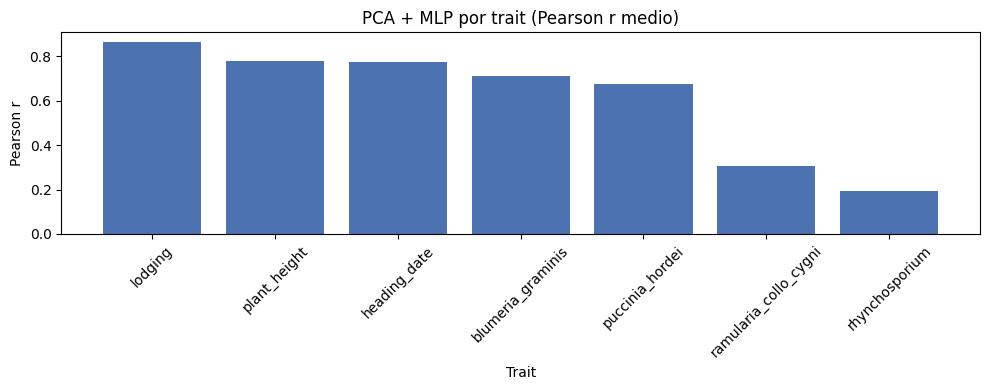

- C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pca_nested5x3\nn_snp_pca_nested5x3_barplot_pearson.png


In [6]:
# 6) Exportacion de resultados y visualizacion rapida

fold_results_df.to_csv(FOLD_RESULTS_CSV, index=False)
inner_best_df.to_csv(INNER_BEST_CSV, index=False)

summary = (
    fold_results_df
    .groupby("trait", as_index=False)
    .agg(
        pearson_r_mean=("pearson_r", "mean"),
        pearson_r_std=("pearson_r", "std"),
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        best_epoch_mean=("best_epoch", "mean"),
        n_components_used_mean=("n_components_used", "mean"),
        pca_var_explained_mean=("pca_var_explained", "mean"),
    )
)
summary.to_csv(SUMMARY_CSV, index=False)

print("Exportes generados:")
print("-", FOLD_RESULTS_CSV)
print("-", INNER_BEST_CSV)
print("-", SUMMARY_CSV)

display(summary.sort_values("trait").reset_index(drop=True))

summary_plot = summary.sort_values("pearson_r_mean", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(summary_plot["trait"], summary_plot["pearson_r_mean"], color="#4C72B0")
ax.set_title("PCA + MLP por trait (Pearson r medio)")
ax.set_ylabel("Pearson r")
ax.set_xlabel("Trait")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(BARPLOT_PNG, dpi=200, bbox_inches="tight")
plt.show()

print("-", BARPLOT_PNG)


## Comparacion con baselines ya disponibles

Si existen los resultados del cuaderno 72 y del baseline GBLUP, el bloque siguiente construye una tabla resumida para apoyar la discusion final del TFM. No modifica archivos previos del proyecto.


,trait,pca_mlp_r,pca_mlp_r2,pca_mlp_rmse,pca_mlp_n_components_mean,pca_mlp_var_mean,mlp_a_r,mlp_a_r2,mlp_a_rmse,gblup_r,gblup_r2,gblup_rmse,delta_vs_mlp_a_r,delta_vs_gblup_r
0,blumeria_graminis,0.712002,0.470701,0.844971,102.4,0.348733,0.742517,0.535497,0.791472,0.763178,0.582337,0.752221,-0.030515,-0.051176
1,heading_date,0.774286,0.593633,20.136904,102.4,0.349429,0.798041,0.627648,19.256234,0.797251,0.634926,19.199901,-0.023755,-0.022964
2,lodging,0.865690,0.729774,0.819361,76.8,0.295951,0.876023,0.762001,0.768932,0.872372,0.760624,0.774439,-0.010333,-0.006681
3,plant_height,0.780727,0.597062,9.028096,76.8,0.296910,0.790891,0.596788,9.036102,0.815771,0.665413,8.289570,-0.010164,-0.035044
4,puccinia_hordei,0.675632,0.426987,0.896089,89.6,0.323479,0.718912,0.476069,0.855008,0.755101,0.569889,0.779544,-0.043280,-0.079469
5,ramularia_collo_cygni,0.304412,0.069203,1.079149,76.8,0.295858,0.338382,0.086338,1.069353,0.385151,0.146777,1.035470,-0.033970,-0.080738
6,rhynchosporium,0.192365,-0.027453,0.912643,76.8,0.295858,0.192231,-0.273445,1.020886,0.273948,0.068389,0.883421,0.000134,-0.081582


- C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pca_nested5x3\nn_snp_pca_vs_baselines.csv


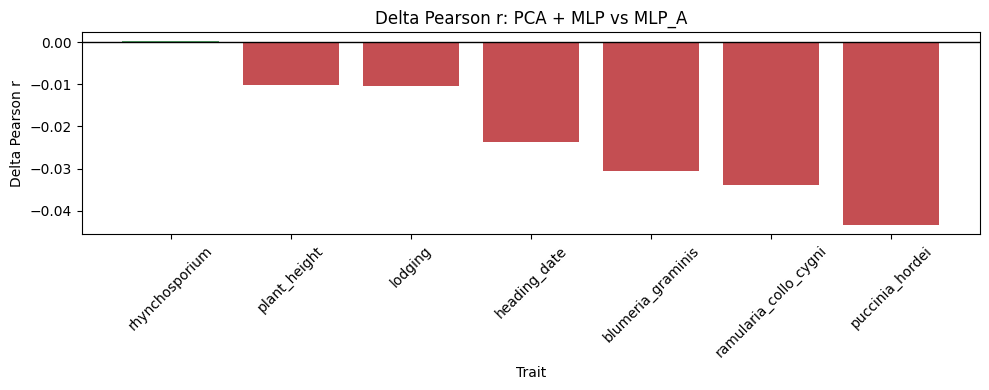

- C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\nested5x3_unificados\results\nn_snp_pca_nested5x3\nn_snp_pca_vs_mlp_a_delta_pearson.png
mean Pearson PCA+MLP: 0.6150
mean Pearson MLP_A: 0.6367


In [7]:
# 7) Comparacion opcional con MLP_A (72) y GBLUP

comparison = summary[[
    "trait",
    "pearson_r_mean",
    "r2_mean",
    "rmse_mean",
    "n_components_used_mean",
    "pca_var_explained_mean",
]].copy()
comparison = comparison.rename(columns={
    "pearson_r_mean": "pca_mlp_r",
    "r2_mean": "pca_mlp_r2",
    "rmse_mean": "pca_mlp_rmse",
    "n_components_used_mean": "pca_mlp_n_components_mean",
    "pca_var_explained_mean": "pca_mlp_var_mean",
})

mlp72_path = BASE_DIR / BASELINE_MLP72_REL
gblup_path = BASE_DIR / BASELINE_GBLUP_REL

if mlp72_path.exists():
    mlp72 = pd.read_csv(mlp72_path)[["trait", "pearson_r_mean", "r2_mean", "rmse_mean"]].copy()
    mlp72 = mlp72.rename(columns={
        "pearson_r_mean": "mlp_a_r",
        "r2_mean": "mlp_a_r2",
        "rmse_mean": "mlp_a_rmse",
    })
    comparison = comparison.merge(mlp72, on="trait", how="left")
else:
    print("[INFO] No se encontro resumen del cuaderno 72.")

if gblup_path.exists():
    gblup = pd.read_csv(gblup_path)[["trait", "pearson_r", "r2", "rmse"]].copy()
    gblup = gblup.rename(columns={
        "pearson_r": "gblup_r",
        "r2": "gblup_r2",
        "rmse": "gblup_rmse",
    })
    comparison = comparison.merge(gblup, on="trait", how="left")
else:
    print("[INFO] No se encontro resumen GBLUP.")

if "mlp_a_r" in comparison.columns:
    comparison["delta_vs_mlp_a_r"] = comparison["pca_mlp_r"] - comparison["mlp_a_r"]

if "gblup_r" in comparison.columns:
    comparison["delta_vs_gblup_r"] = comparison["pca_mlp_r"] - comparison["gblup_r"]

comparison = comparison.sort_values("trait").reset_index(drop=True)
comparison.to_csv(COMPARISON_CSV, index=False)

display(comparison)
print("-", COMPARISON_CSV)

if "delta_vs_mlp_a_r" in comparison.columns and comparison["delta_vs_mlp_a_r"].notna().any():
    cmp_plot = comparison.sort_values("delta_vs_mlp_a_r", ascending=False).reset_index(drop=True)
    colors = np.where(cmp_plot["delta_vs_mlp_a_r"] >= 0, "#55A868", "#C44E52")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(cmp_plot["trait"], cmp_plot["delta_vs_mlp_a_r"], color=colors)
    ax.axhline(0.0, color="black", linewidth=1.0)
    ax.set_title("Delta Pearson r: PCA + MLP vs MLP_A")
    ax.set_ylabel("Delta Pearson r")
    ax.set_xlabel("Trait")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    fig.savefig(COMPARISON_PNG, dpi=200, bbox_inches="tight")
    plt.show()

    print("-", COMPARISON_PNG)
    print(f"mean Pearson PCA+MLP: {comparison['pca_mlp_r'].mean():.4f}")
    print(f"mean Pearson MLP_A: {comparison['mlp_a_r'].dropna().mean():.4f}")


## Interpretación de los resultados

- Si el nuevo modelo mejora el `Pearson r` medio respecto a `MLP_A`, la compresion previa ha ayudado a estabilizar el aprendizaje.
- Si el nuevo modelo sigue por debajo de `GBLUP`, la lectura correcta no es que la red sea inutil, sino que el baseline aditivo sigue siendo muy competitivo en este material.
